
Model Comparison:

           Model  Accuracy  Precision  Recall  F1-score
0            SVM      0.95       0.95    0.95      0.95
1  Random Forest      0.93       0.93    0.93      0.93
2           LSTM      0.93       0.93    0.93      0.93


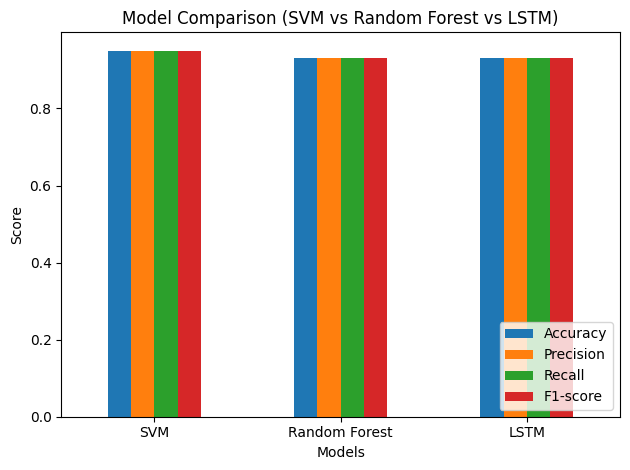

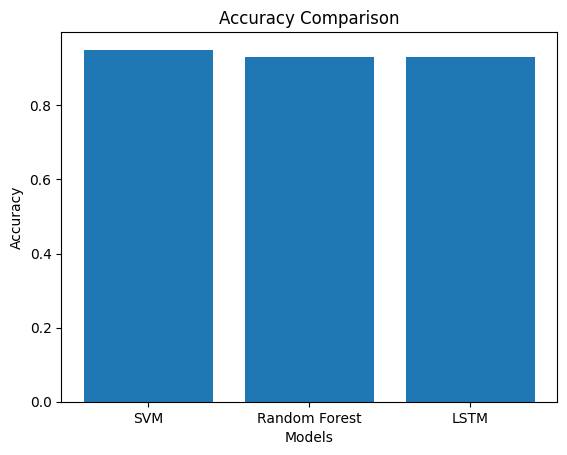

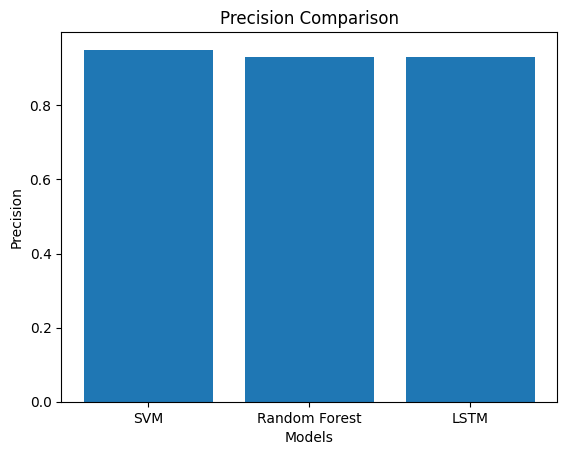

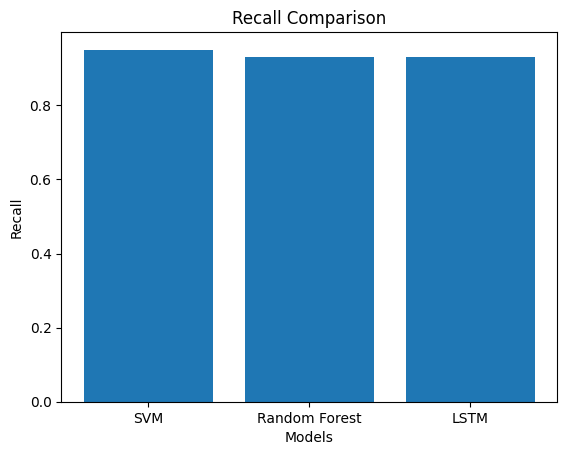

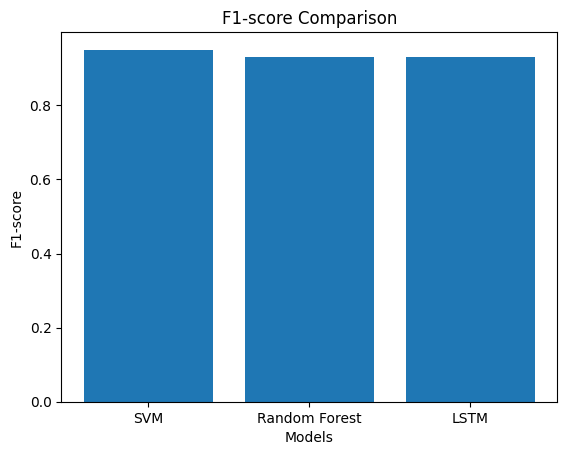

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# FUNCTION: READ CLASSIFICATION REPORT
# -----------------------
def read_report(file_path):
    metrics = {}

    with open(file_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        # Skip empty lines
        if line == "":
            continue

        # Extract accuracy
        if line.startswith("accuracy"):
            parts = line.split()
            # format: accuracy   0.94   1000
            metrics["Accuracy"] = float(parts[1])

        # Extract weighted avg (overall metrics)
        elif line.startswith("weighted avg"):
            parts = line.split()
            # format: weighted avg  precision recall f1-score support
            metrics["Precision"] = float(parts[2])
            metrics["Recall"] = float(parts[3])
            metrics["F1-score"] = float(parts[4])

    return metrics


# -----------------------
# LOAD FILES
# -----------------------
svm = read_report("svm_report.txt")
rf = read_report("rf_report.txt")
lstm = read_report("lstm_report.txt")


# -----------------------
# CREATE DATAFRAME
# -----------------------
df = pd.DataFrame([
    ["SVM", svm["Accuracy"], svm["Precision"], svm["Recall"], svm["F1-score"]],
    ["Random Forest", rf["Accuracy"], rf["Precision"], rf["Recall"], rf["F1-score"]],
    ["LSTM", lstm["Accuracy"], lstm["Precision"], lstm["Recall"], lstm["F1-score"]],
], columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

print("\nModel Comparison:\n")
print(df)


# -----------------------
# PLOT COMBINED GRAPH
# -----------------------
df.set_index("Model").plot(kind="bar")

plt.title("Model Comparison (SVM vs Random Forest vs LSTM)")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


# -----------------------
# OPTIONAL: INDIVIDUAL PLOTS
# -----------------------
metrics_list = ["Accuracy", "Precision", "Recall", "F1-score"]

for metric in metrics_list:
    plt.figure()
    plt.bar(df["Model"], df[metric])
    plt.title(f"{metric} Comparison")
    plt.xlabel("Models")
    plt.ylabel(metric)
    plt.show()